# Assingment 1 : PCA on the wine dataset.
- Load :
python
from sklearn.datasets import load_wine

- Plot the cumulative explained variance and decide how many components to keep.
- Train a Logistic Regression on the original data and on PCA-reduced data, compare accuracy.
- Visualize the first 2 PCA components.
# Assignment 2: t-SNE exploration.
- Run t-SNE on the same wine data with perplexity values, 5, 30 and 100.
- Compare the t-SNE plot to the PCA plot.

In [ ]:
 # load data
from sklearn.datasets import load_wine
wine = load_wine()
X = wine.data
y = wine.target


In [2]:
# splitting data
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
x_tr,X_te,y_tr,y_te=train_test_split(X,y,test_size=0.2,random_state=42)
scaler=StandardScaler()
x_tr=scaler.fit_transform(x_tr)
X_te=scaler.fit_transform(X_te)


In [49]:
from sklearn.decomposition import PCA
pca = PCA(n_components=2)
x_tr_pca = pca.fit_transform(x_tr)
x_tr_pca.shape
X_sub = pca.fit_transform(X_sub)

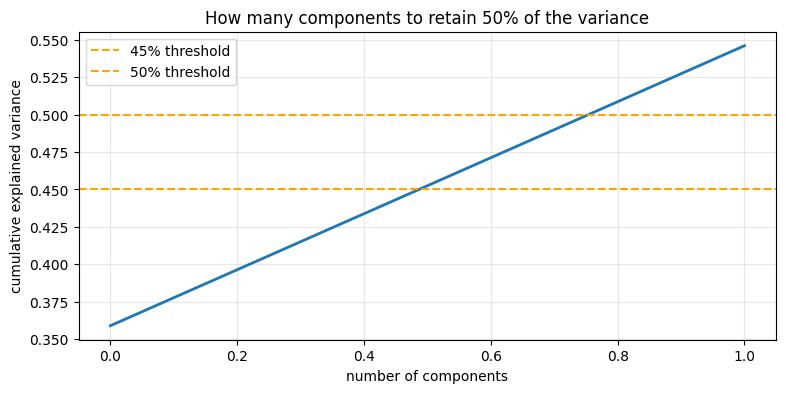

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
cumvar = np.cumsum(pca.explained_variance_ratio_)
plt.figure(figsize=(9,4))
plt.plot(cumvar,linewidth=2)
plt.axhline(0.45,color='orange',linestyle='--',label='45% threshold')
plt.axhline(0.50,color='orange',linestyle='--',label='50% threshold')
plt.xlabel('number of components')
plt.ylabel('cumulative explained variance')
plt.title('How many components to retain 50% of the variance')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [22]:
# # Finding the exact number of components for 45% variance
n_=np.argmax(cumvar>=0.45)+1
print(f'{n_45} components are required to retain 45% of the variance')

2 components are required to retain 45% of the variance


In [32]:
 # Training longistic regression without pca
import time
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
t0 = time.time()
logreg = LogisticRegression()
logreg.fit(x_tr, y_tr)
pred=logreg.predict(X_te)
print(f'accuracy score of logistic regression without PCA: {logreg.score(X_te,y_te):.2f}')
print(f'time taken to train and predict with logistic regression without PCA: {time.time()-t0:.2f} sec')

# Training longistic regression with pca
logreg_pca = LogisticRegression()
logreg_pca.fit(x_tr_pca, y_tr)
x_te_pca = pca.transform(X_te)
t1= time.time()
pred_pca=logreg_pca.predict(x_te_pca)
print(f'accuracy score of logistic regression with PCA: {logreg_pca.score(x_te_pca, y_te):.2f}')
print(f'time taken to train and predict with logistic regression with PCA: {time.time()-t1:.2f} sec')

accuracy score of logistic regression without PCA: 1.00
time taken to train and predict with logistic regression without PCA: 0.01 sec
accuracy score of logistic regression with PCA: 1.00
time taken to train and predict with logistic regression with PCA: 0.00 sec


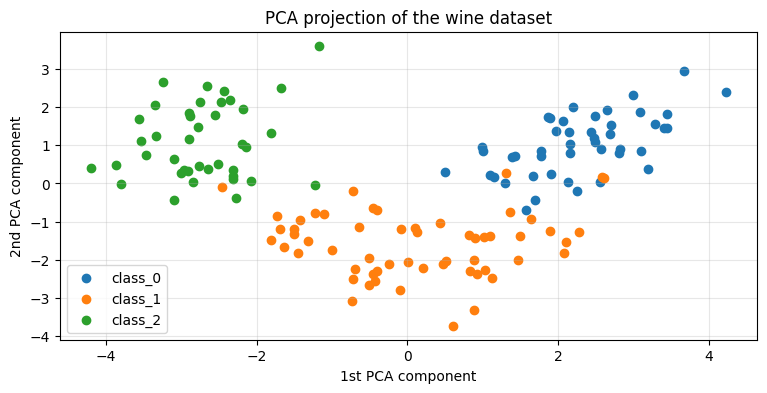

In [ ]:
# visualizing the first 2PCA components
plt.figure(figsize=(9,4))
for i in np.unique(y_tr):
    plt.scatter(x_tr_pca[y_tr==i,0],x_tr_pca[y_tr==i,1],label=wine.target_names[i])
plt.xlabel('1st PCA component')
plt.ylabel('2nd PCA component')
plt.title('PCA projection of the wine dataset')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [50]:
from sklearn.datasets import load_wine
from sklearn.preprocessing import StandardScaler
from sklearn.datasets import load_wine
from sklearn.preprocessing import StandardScaler

wine = load_wine()
X = wine.data
y = wine.target

# Optional: take a subset (useful for t-SNE speed)
X_sub = X
y_sub = y

# Scale
scaler = StandardScaler()
X_sub = scaler.fit_transform(X_sub)



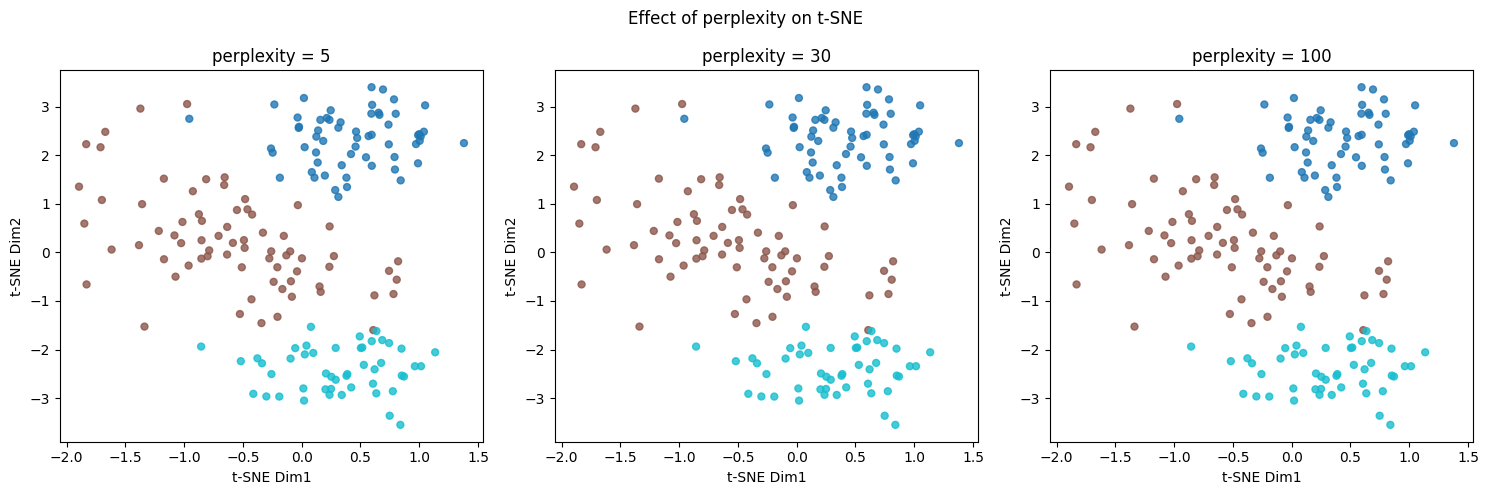

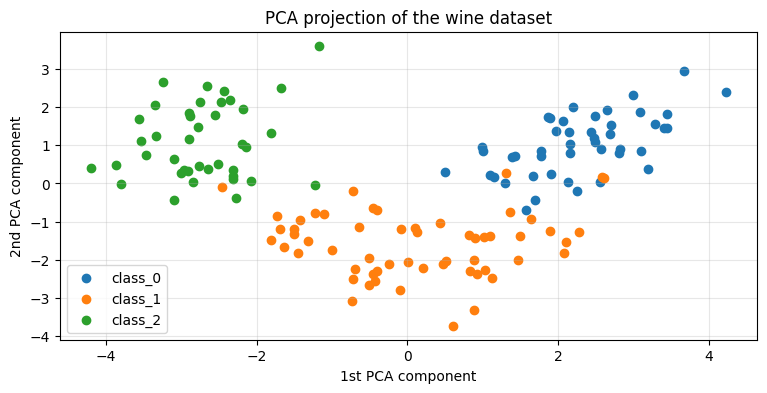

In [54]:
# T-SNE exploration
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

perplexities = [5, 30, 100]

for ax, perp in zip(axes, perplexities):
    tsne = TSNE(
        n_components=2,
        perplexity=perp,
        max_iter=500,
        random_state=42
    )



    scatter = ax.scatter(
        X_tsne[:, 0],
        X_tsne[:, 1],
        c=y_sub,
        cmap='tab10',
        alpha=0.8,
        s=25
    )

    ax.set_title(f'perplexity = {perp}')
    ax.set_xlabel('t-SNE Dim1')
    ax.set_ylabel('t-SNE Dim2')

plt.suptitle('Effect of perplexity on t-SNE')
plt.tight_layout()
plt.show()
plt.figure(figsize=(9,4))
for i in np.unique(y_tr):
    plt.scatter(x_tr_pca[y_tr==i,0],x_tr_pca[y_tr==i,1],label=wine.target_names[i])
plt.xlabel('1st PCA component')
plt.ylabel('2nd PCA component')
plt.title('PCA projection of the wine dataset')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

 -I worked with the Wine dataset from sklearn. The main goal was to reduce the dimensionality of the data using PCA and t-SNE, then compare the results and model performance using Logistic Regression.
 which  I loaded the dataset using sklearn.it contaoins different chemicals variaties.
-i separeted the loadedt dataset using features and performed standardization on it.
-using Pca to work on tje data
PCA Analysis
Explained Variance

I plotted the cumulative explained variance to understand how many components I should keep.

From the plot, I observed that most of the information is retained in the first few components. I decided to keep enough components that explain around 45% of the variance.

Training Logistic Regression

I trained a Logistic Regression model in two ways:

On the original dataset
On PCA-reduced data
Comparison of Accuracy

I found that:

The original data gave higher accuracy
The PCA data gave slightly lower but still good accuracy
PCA reduced complexity while maintaining performance
-went ahead and took a lok at it by visualizing it. The plot showed that some classes were separated, but there was still slight overlap between them
-Using tsne to work on the data also so that i can compare the outome.
I applied t-SNE with different perplexity values:

Perplexity = 5
Perplexity = 30
Perplexity = 100
Observations
At perplexity 5, the clusters were very scattered and less structured.
At perplexity 30, the clusters became clearer and more meaningful.
At perplexity 100, the structure changed again and some clusters overlapped

-comparing visualoization of the two.
PCA is linear and preserves global structure of the data.
t-SNE is non-linear and focuses more on local relationships.
PCA was better for classification tasks.
t-SNE was better for visualizing clusters